# Generalized Hough Transform with Scale and Rotation

In [ ]:
# Meta / Paths
from pathlib import Path
DATASET_DIR = Path("path/to/dataset")  # change this to your dataset path
OUTPUT_DIR  = Path("outputs")      # results will be saved here

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("DATASET_DIR:", DATASET_DIR.resolve())
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())

## 1) Introduction
This notebook implements the Generalized Hough Transform (GHT) to detect a template object in a scene, handling discrete scales and rotations:
- Scales: `1.0, 1.5, 2.0, 3.0`
- Rotations: multiples of `15°` in `[0°, 15°, ..., 345°]`

We first compute edge maps for the template and the scenes. We then build an R-table that maps edge gradient directions to displacement vectors to a chosen reference point (template center). During detection, each scene edge point votes for possible object centers over the discretized `(x, y, scale, rotation)` space. Peaks indicate detections.


## 2) Imports and small utilities

In [3]:
# imports
import math
import numpy as np
import cv2
import matplotlib.pyplot as plt

from typing import Dict, List, Tuple
from pathlib import Path
from dataclasses import dataclass

plt.rcParams["figure.dpi"] = 120

def imread_gray(path: Path) -> np.ndarray:
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Could not read image: {path}")
    return img

def show_image(title: str, img: np.ndarray, cmap='gray'):
    plt.figure()
    plt.title(title)
    plt.imshow(img, cmap=cmap)
    plt.axis('off')
    plt.show()

## 3) Edge Detection

I decided to use Canny.

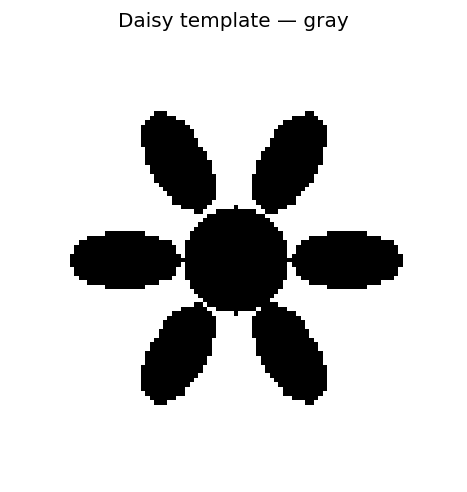

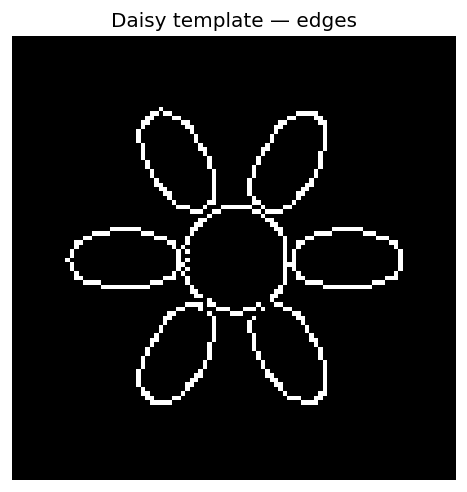

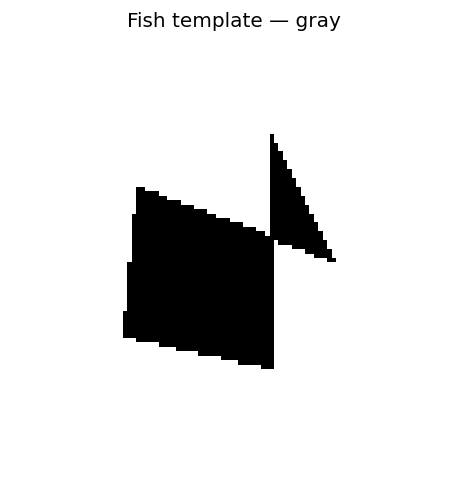

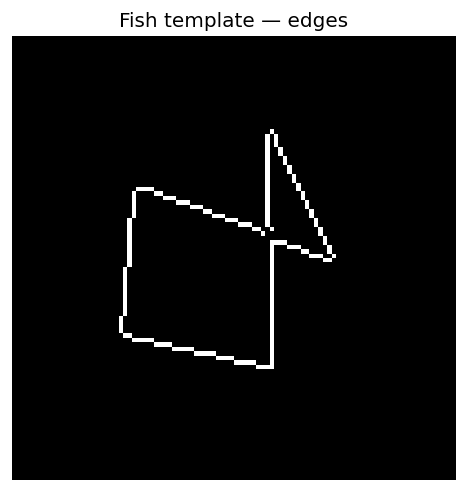

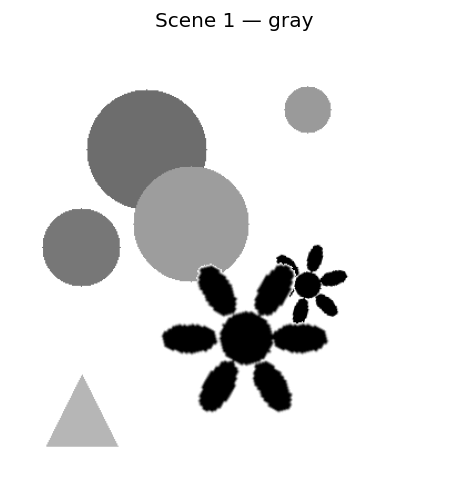

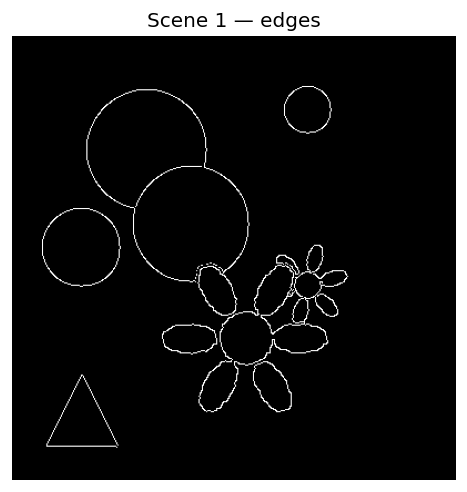

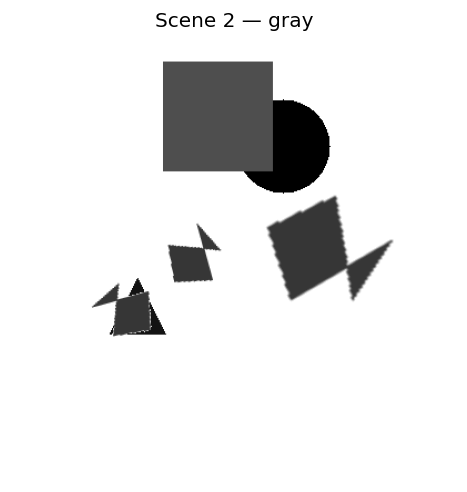

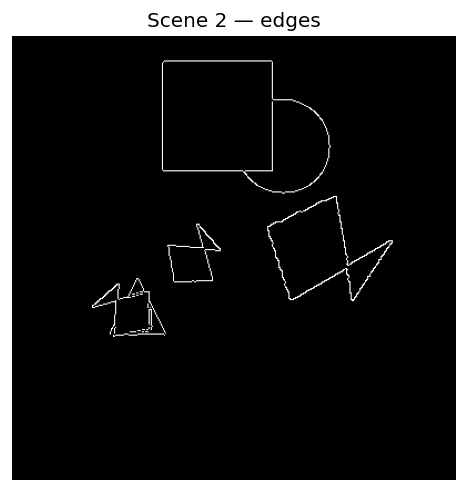

In [4]:
def edge_map_canny(gray: np.ndarray, low: int=50, high: int=150) -> np.ndarray:
    edges = cv2.Canny(gray, threshold1=low, threshold2=high, L2gradient=True)
    return edges

def gradient_orientation(gray: np.ndarray) -> np.ndarray:
    # Sobel gradients for orientation
    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    angles = cv2.phase(gx, gy, angleInDegrees=True)  # [0, 360)
    return angles

daisy_template_path = DATASET_DIR / "dataset_daisy" / "template.png"
daisy_scene_paths   = sorted((DATASET_DIR / "dataset_daisy").glob("scene_*.png"))

fish_template_path  = DATASET_DIR / "dataset_fish" / "template.png"
fish_scene_paths    = sorted((DATASET_DIR / "dataset_fish").glob("scene_*.png"))

try:
    tmpl = imread_gray(daisy_template_path)
    tmp2 = imread_gray(fish_template_path)
    sc1  = imread_gray(daisy_scene_paths[0])
    sc2  = imread_gray(fish_scene_paths[1])

    tmpl_edges = edge_map_canny(tmpl)
    tmp2_edges = edge_map_canny(tmp2)
    sc1_edges  = edge_map_canny(sc1)
    sc2_edges  = edge_map_canny(sc2)

    show_image("Daisy template — gray", tmpl)
    show_image("Daisy template — edges", tmpl_edges)

    show_image("Fish template — gray", tmp2)
    show_image("Fish template — edges", tmp2_edges)

    show_image("Scene 1 — gray", sc1)
    show_image("Scene 1 — edges", sc1_edges)

    show_image("Scene 2 — gray", sc2)
    show_image("Scene 2 — edges", sc2_edges)
except Exception as e:
    print("Demo edge display skipped:", e)

## 4) GHT: R-table construction
For each edge pixel in the template:
1. Compute its gradient orientation (quantized to bins).
2. Store the vector from the edge pixel to the template reference point (center).

In [ ]:
# 180°-periodic bins
NUM_BINS = 36
BIN_W = 180.0 / NUM_BINS
SCALES = [1.0, 1.5, 2.0, 3.0]
ROTS   = list(range(0, 360, 15))
MIN_SUPPORT_RATIO = 0.07 
THR_RATIO = 0.18
NMS_RADIUS = 12
CANNY_LOW = 50
CANNY_HIGH = 150
MAG_THR_RATIO = 0.18            
DRAW_BOX = True            
ALPHA = 2.5

# Normalization function used for fish template
def min_support_norm(scale: float, alpha: float = ALPHA) -> float:
    return MIN_SUPPORT_RATIO / (scale ** alpha)

def normalize_accs(accs: Dict[tuple, np.ndarray],
                   template_edges: np.ndarray,
                   alpha: float = ALPHA) -> Dict[tuple, np.ndarray]:
    N_t = int((template_edges > 0).sum())
    out = {}
    norm_base = max(1.0, float(N_t))
    for (rot, sc), acc in accs.items():
        out[(rot, sc)] = acc.astype(np.float32) / (norm_base * (sc ** alpha))
    return out

def quantize_angle(a_deg: float, num_bins: int = NUM_BINS) -> int:
    a = a_deg % 180.0
    return int(a // (180.0/num_bins)) % num_bins

# R-table construction
def build_r_table(template_gray, edge_map, num_bins=NUM_BINS, ref_point=None):
    h, w = template_gray.shape[:2]
    if ref_point is None:
        ref_point = (w//2, h//2)
    angles = gradient_orientation(template_gray)
    # keep most edges, avoid aggressive pruning
    ys, xs = np.where(edge_map > 0)
    rtable = {b: [] for b in range(num_bins)}
    for y, x in zip(ys, xs):
        b = quantize_angle(angles[y, x], num_bins)
        rtable[b].append((ref_point[0]-x, ref_point[1]-y))
    return rtable

# Weighted R-table construction
def build_r_table_weighted(template_gray, edge_map, num_bins=NUM_BINS, ref_point=None, mag_thr_ratio=MAG_THR_RATIO):
    h, w = template_gray.shape[:2]
    if ref_point is None:
        ref_point = (w//2, h//2)
    gx = cv2.Sobel(template_gray, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(template_gray, cv2.CV_32F, 0, 1, ksize=3)
    mag = cv2.magnitude(gx, gy)
    ang = gradient_orientation(template_gray)  # 0..360

    thr = float(mag.max()) * mag_thr_ratio
    ys, xs = np.where((edge_map > 0) & (mag >= thr))

    rtable = {b: [] for b in range(num_bins)}  # store (dx,dy,w)
    for y, x in zip(ys, xs):
        b = quantize_angle(ang[y, x], num_bins)
        wgt = float(mag[y, x])
        rtable[b].append((ref_point[0] - x, ref_point[1] - y, wgt))
    return rtable

## 5) GHT: Voting with scale and rotation
For each **scene edge pixel** and each `(scale, rotation)` pair:
1. Compute the **rotated and scaled** displacement vectors from the R-table bin that matches the pixel's orientation.
2. Vote for the corresponding center `(cx, cy)` in the accumulator.
Peaks in the 2D accumulator indicate likely centers for that `(scale, rotation)`.


In [13]:
def rotate_vector(dx: float, dy: float, theta_deg: float) -> Tuple[float,float]:
    th = math.radians(theta_deg)
    c, s = math.cos(th), math.sin(th)
    rx = c*dx - s*dy
    ry = s*dx + c*dy
    return rx, ry

def detect_ght(scene_gray, rtable, num_bins=NUM_BINS,
               scales=SCALES, rotations=ROTS,
               canny_low=CANNY_LOW, canny_high=CANNY_HIGH, blur_sigma=1.0):
    H, W = scene_gray.shape[:2]
    edges  = edge_map_canny(scene_gray, canny_low, canny_high)
    angles = gradient_orientation(scene_gray)
    ys, xs = np.where(edges > 0)
    accs = {}
    for rot in rotations:
        shift = int(round((rot % 180) / BIN_W)) % num_bins
        for sc in scales:
            acc = np.zeros((H, W), dtype=np.float32)
            for y, x in zip(ys, xs):
                b_scene = quantize_angle(angles[y, x], num_bins)
                b_tmpl  = (b_scene - shift) % num_bins
                for dx, dy in rtable.get(b_tmpl, []):
                    rx, ry = rotate_vector(dx*sc, dy*sc, rot)
                    cx = int(round(x + rx)); cy = int(round(y + ry))
                    if 0 <= cx < W and 0 <= cy < H:
                        acc[cy, cx] += 1.0
            accs[(rot, sc)] = cv2.GaussianBlur(acc, (0, 0), blur_sigma)
    return accs

def detect_ght_weighted(scene_gray, rtable, num_bins=NUM_BINS,
                        scales=SCALES, rotations=ROTS,
                        canny_low=CANNY_LOW, canny_high=CANNY_HIGH, blur_sigma=1.2):
    H, W = scene_gray.shape[:2]
    edges  = edge_map_canny(scene_gray, canny_low, canny_high)
    gx = cv2.Sobel(scene_gray, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(scene_gray, cv2.CV_32F, 0, 1, ksize=3)
    mag   = cv2.magnitude(gx, gy)
    ang   = cv2.phase(gx, gy, angleInDegrees=True)

    ys, xs = np.where(edges > 0)
    accs = {}
    for rot in rotations:
        shift = int(round((rot % 180) / BIN_W)) % num_bins
        for sc in scales:
            acc = np.zeros((H, W), dtype=np.float32)
            for y, x in zip(ys, xs):
                b_scene = quantize_angle(ang[y, x], num_bins)
                b_tmpl  = (b_scene - shift) % num_bins
                for dx, dy, w in rtable.get(b_tmpl, []):
                    rx, ry = rotate_vector(dx*sc, dy*sc, rot)
                    cx = int(round(x + rx)); cy = int(round(y + ry))
                    if 0 <= cx < W and 0 <= cy < H:
                        acc[cy, cx] += w * float(mag[y, x] + 1e-6)
            accs[(rot, sc)] = cv2.GaussianBlur(acc, (0, 0), blur_sigma)
    return accs


## 6) Peak finding and visualization
We find the maximum vote for each `(rotation, scale)` accumulator, select the global best, and visualize:
- Accumulator heatmap
- Detection overlay on the scene


In [ ]:
def find_best_peak(accs: Dict[Tuple[int,float], np.ndarray]):
    best_key, best_val, best_loc = None, -1, None
    for key, acc in accs.items():
        minVal, maxVal, minLoc, maxLoc = cv2.minMaxLoc(acc.astype(np.float32))
        if maxVal > best_val:
            best_val = maxVal
            best_loc = maxLoc  # (x, y)
            best_key = key
    return best_key, best_val, best_loc  # ((rot, scale), votes, (x, y))

def verify_candidate(scene_edges: np.ndarray, template_edges: np.ndarray,
                     center_xy, rot_deg, scale, ref_point=None) -> float:
    # low score = good
    H, W = scene_edges.shape[:2]
    dt = cv2.distanceTransform((255 - (scene_edges>0).astype(np.uint8)*255), cv2.DIST_L2, 3)

    h, w = template_edges.shape[:2]
    if ref_point is None:
        ref_point = (w//2, h//2)

    ys, xs = np.where(template_edges > 0)
    th = np.deg2rad(rot_deg); c, s = np.cos(th), np.sin(th)
    cx, cy = center_xy
    errs = []
    for y, x in zip(ys, xs):
        dx, dy = (x - ref_point[0]) * scale, (y - ref_point[1]) * scale
        rx =  c*dx - s*dy
        ry =  s*dx + c*dy
        u = int(round(cx + rx)); v = int(round(cy + ry))
        if 0 <= u < W and 0 <= v < H:
            errs.append(dt[v, u])
        else:
            errs.append(5.0)
    return float(np.mean(errs)) if errs else 1e9


def top_peaks(acc, k=6, radius=12, thr_ratio=0.35, min_votes=None):
    accf = acc.astype(np.float32)
    kernel = np.ones((2*radius+1, 2*radius+1), np.uint8)
    dil = cv2.dilate(accf, kernel)
    thr = max(accf.max()*thr_ratio, float(min_votes or 0))
    mask = (accf == dil) & (accf >= thr)
    ys, xs = np.where(mask)
    vals = accf[ys, xs]
    order = np.argsort(-vals)[:k]
    return [(int(xs[i]), int(ys[i]), float(vals[i])) for i in order]

def detect_all(scene_gray, scene_bgr, rtable):
    accs = detect_ght(scene_gray, rtable)
    detections = []  # (x,y,rot,scale,votes)
    for (rot, sc), acc in accs.items():
        for x, y, v in top_peaks(acc, k=5, radius=12, thr_ratio=0.6):
            detections.append((x, y, rot, sc, v))
    merged = []
    for x,y,rot,sc,v in sorted(detections, key=lambda t:-t[4]):
        if all((abs(x-x2)>15 or abs(y-y2)>15 or sc!=sc2) for x2,y2,rot2,sc2,v2 in merged):
            merged.append((x,y,rot,sc,v))
    for x,y,rot,sc,v in merged:
        vis = draw_detection(scene_bgr, (x,y))
    return merged, accs

def draw_detection(scene_bgr: np.ndarray,
                   center_xy: Tuple[int,int],
                   color=(0,0,255),
                   r=6, thickness=2):
    vis = scene_bgr.copy()
    cx, cy = center_xy
    cv2.circle(vis, (cx, cy), r, color, thickness, lineType=cv2.LINE_AA)
    cv2.drawMarker(vis, (cx, cy), color, markerType=cv2.MARKER_TILTED_CROSS, markerSize=16, thickness=2)
    return vis

def show_accumulator_heatmap(acc: np.ndarray, title: str="Accumulator"):
    plt.figure()
    plt.title(title)
    plt.imshow(acc, cmap="hot")
    plt.colorbar()
    plt.axis('off')
    plt.show()

def draw_rotated_bbox(img_bgr, center_xy, tmpl_wh, scale, rot_deg, color=(0,255,0), thickness=2):
    w, h = tmpl_wh
    w2, h2 = (w*scale)/2.0, (h*scale)/2.0
    corners = np.array([[-w2,-h2],[w2,-h2],[w2,h2],[-w2,h2]], dtype=np.float32)
    th = np.deg2rad(rot_deg)
    R = np.array([[np.cos(th), -np.sin(th)],[np.sin(th), np.cos(th)]], dtype=np.float32)
    rc = (corners @ R.T) + np.array(center_xy, dtype=np.float32)
    rc = rc.astype(int)
    cv2.polylines(img_bgr, [rc], True, color, thickness, lineType=cv2.LINE_AA)
    return img_bgr

def merge_candidates(cands, tmpl_diag):
    # cands: [(x,y,rot,sc,votes), ...]
    cands.sort(key=lambda t: -t[4])
    final = []
    for c in cands:
        x1,y1,_,sc1,_ = c
        keep = True
        for x2,y2,_,sc2,_ in final:
            R = 0.30 * tmpl_diag * max(sc1, sc2)
            if (x1-x2)**2 + (y1-y2)**2 <= R*R:
                keep = False
                break
        if keep:
            final.append(c)
    return final

## 7) End-to-end example on one image
Run R-table construction on the template, then run detection on a scene image. Show:
- Accumulator heatmap of the best `(rotation, scale)`
- Final detection overlay


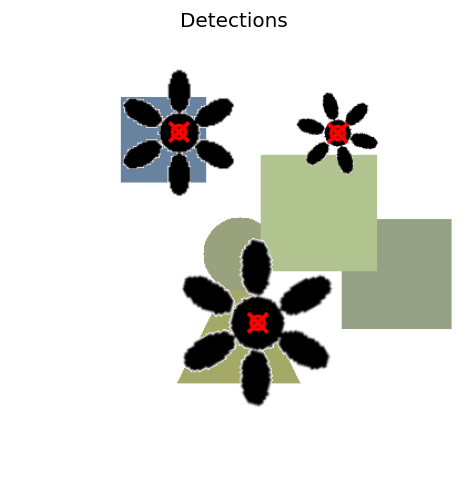

Detected centers: [(293, 87, 255, 1.0, 44), (221, 258, 330, 2.0, 38), (150, 86, 270, 1.5, 32)]


In [ ]:
# Template → R-table
template_gray  = imread_gray(daisy_template_path)
template_edges = edge_map_canny(template_gray)
rtable = build_r_table(template_gray, template_edges, num_bins=NUM_BINS)

scene_path = daisy_scene_paths[11]
scene_gray = imread_gray(scene_path)
scene_bgr  = cv2.imread(str(scene_path), cv2.IMREAD_COLOR)

accs = detect_ght(scene_gray, rtable)

N_t = int((template_edges > 0).sum())
min_support = max(10, int(N_t * MIN_SUPPORT_RATIO))

# collect peaks from every (rot, scale)
cands = []
for (rot, sc), acc in accs.items():
    # scale-aware NMS radius
    base_r = 12
    peaks = top_peaks(acc, k=6, radius=int(round(base_r*sc)),
                      thr_ratio=0.18, min_votes=min_support)
    for x, y, v in peaks:
        cands.append((x, y, rot, sc, v))

# fallback if empty : use best grid global max
if not cands:
    key = max(accs, key=lambda k: accs[k].max())
    acc = accs[key]
    _, _, _, maxLoc = cv2.minMaxLoc(acc)
    x, y = maxLoc
    rot, sc = key
    cands = [(x, y, rot, sc, float(acc[y, x]))]

# merge nearby centers across grids
h, w = template_gray.shape[:2]
tmpl_diag = (h*h + w*w) ** 0.5
cands.sort(key=lambda t: -t[4])
final = []
for c in cands:
    x1,y1,_,sc1,_ = c
    keep = True
    for x2,y2,_,sc2,_ in final:
        R = 0.30 * tmpl_diag * max(sc1, sc2)  # merge radius
        if (x1-x2)**2 + (y1-y2)**2 <= R*R:
            keep = False
            break
    if keep:
        final.append(c)

# draw and save
vis = scene_bgr.copy()
for x, y, _, _, _ in final:
    vis = draw_detection(vis, (x, y))

best_key = max(accs, key=lambda k: accs[k].max())
plt.imsave((OUTPUT_DIR/"acc_heatmap_best.png").as_posix(),
           accs[best_key].astype(np.float32), cmap="hot")
cv2.imwrite((OUTPUT_DIR/"detection_overlay.png").as_posix(), vis)
show_image("Detections", cv2.cvtColor(vis, cv2.COLOR_BGR2RGB), cmap=None)
print("Detected centers:", [(x,y,rot,sc,int(v)) for x,y,rot,sc,v in final])


## 8) GHT detections on multiple scenes
For each test:
- Show accumulator heatmap for the best `(rotation, scale)`
- Show final detection overlay and print center coordinates
Write short comments below each result.


In [ ]:
def run_dataset(template_path: Path, scene_paths: List[Path], tag: str):
    out_dir = OUTPUT_DIR / tag
    out_dir.mkdir(parents=True, exist_ok=True)

    # template : R-table
    try:
        template_gray  = imread_gray(template_path)
        template_edges = edge_map_canny(template_gray)
        rtable = build_r_table(template_gray, template_edges, num_bins=NUM_BINS, ref_point=None)
    except Exception as e:
        print(f"[{tag}] Template load/build failed:", e); return

    th, tw = template_gray.shape[:2]
    tmpl_diag = (th*th + tw*tw) ** 0.5
    N_t = int((template_edges > 0).sum())
    min_support = max(10, int(N_t * MIN_SUPPORT_RATIO))

    for sp in scene_paths:
        try:
            sg = imread_gray(sp)
            sb = cv2.imread(str(sp), cv2.IMREAD_COLOR)

            # voting over discrete grid
            accs = detect_ght(sg, rtable,
                              num_bins=NUM_BINS, scales=SCALES, rotations=ROTS,
                              canny_low=CANNY_LOW, canny_high=CANNY_HIGH)

            # collect peaks from every grid
            cands = []
            for (rot, sc), acc in accs.items():
                peaks = top_peaks(acc, k=6, radius=int(round(NMS_RADIUS*sc)),
                                  thr_ratio=THR_RATIO, min_votes=min_support)
                for x, y, v in peaks:
                    cands.append((x, y, rot, sc, v))

            # fallback to strongest grid if nothing survived
            if not cands:
                key = max(accs, key=lambda k: accs[k].max())
                acc = accs[key]
                _, _, _, maxLoc = cv2.minMaxLoc(acc)
                x, y = maxLoc
                rot, sc = key
                cands = [(x, y, rot, sc, float(acc[y, x]))]

            final = merge_candidates(cands, tmpl_diag)

            # print centers
            print(f"[{tag}] {sp.name}: {len(final)} detections")
            for (x, y, rot, sc, v) in final:
                print(f"  Detected center: ({x}, {y})  rot={rot}°  scale={sc}  votes={int(v)}")

            # draw centers (+ optional bbox)
            vis = sb.copy()
            for (x, y, rot, sc, _) in final:
                vis = draw_detection(vis, (x, y), color=(0,0,255))
                if DRAW_BOX:
                    vis = draw_rotated_bbox(vis, (x, y), tmpl_wh=(tw, th), scale=sc, rot_deg=rot, color=(0,255,0))

            # save and show: best accumulator heatmap + overlay
            best_key = max(accs, key=lambda k: accs[k].max())
            best_acc = accs[best_key]
            heat_path = out_dir / f"{sp.stem}_acc_heatmap.png"
            det_path  = out_dir / f"{sp.stem}_detections.png"
            plt.imsave(heat_path.as_posix(), best_acc.astype(np.float32), cmap="hot")
            cv2.imwrite(det_path.as_posix(), vis)

            show_accumulator_heatmap(best_acc, title=f"{tag} — {sp.name} — rot {best_key[0]}°, scale {best_key[1]}")
            show_image(f"{tag} — {sp.name} — detections", cv2.cvtColor(vis, cv2.COLOR_BGR2RGB), cmap=None)
            print("Saved:", heat_path.name, det_path.name)

        except Exception as e:
            print(f"[{tag}] Failed on {sp}:", e)

def run_dataset_fish_robust(template_path: Path, scene_paths: List[Path], tag: str):
    out_dir = OUTPUT_DIR / tag
    out_dir.mkdir(parents=True, exist_ok=True)

    # template : weighted R-table
    template_gray  = imread_gray(template_path)
    template_edges = edge_map_canny(template_gray)
    rtable = build_r_table_weighted(template_gray, template_edges,
                                    num_bins=NUM_BINS, ref_point=None, mag_thr_ratio=MAG_THR_RATIO)

    th, tw = template_gray.shape[:2]
    tmpl_diag = (th*th + tw*tw) ** 0.5
    N_t = int((template_edges > 0).sum())
    min_support = max(10, int(N_t * 0.12))

    for sp in scene_paths:
        sg = imread_gray(sp)
        sb = cv2.imread(str(sp), cv2.IMREAD_COLOR)

        # weighted voting
        accs = detect_ght_weighted(sg, rtable, num_bins=NUM_BINS,
                                   scales=SCALES, rotations=ROTS, blur_sigma=1)

        # gather peaks from all grids
        cands = []
        edges_scene = edge_map_canny(sg)
        for (rot, sc), acc in accs.items():
            peaks = top_peaks(acc, k=6, radius=int(round(12*sc)),
                              thr_ratio=0.3, min_votes=min_support_norm(sc,ALPHA))
            for x, y, v in peaks:
                cands.append((x, y, rot, sc, v))

        # DT verification
        scored = []
        for x, y, rot, sc, v in cands:
            score = verify_candidate(edges_scene, template_edges, (x, y), rot, sc)
            scored.append((score, x, y, rot, sc, v))
        scored.sort()
        keep = [t for t in scored if t[0] <= (scored[0][0] * 1.6 if scored else 1e9) and (not scored or t[0] <= 2.0)]

        # merge duplicates; fallback if empty
        final = merge_candidates([(x,y,rot,sc,v) for _,x,y,rot,sc,v in keep], tmpl_diag)
        if not final:
            key = max(accs, key=lambda k: accs[k].max())
            acc = accs[key]; _, _, _, maxLoc = cv2.minMaxLoc(acc); x,y = maxLoc
            rot, sc = key; final = [(x,y,rot,sc,float(acc[y,x]))]

        # draw overlay
        vis = sb.copy()
        for x, y, rot, sc, _ in final:
            vis = draw_detection(vis, (x, y), color=(0,0,255))
            vis = draw_rotated_bbox(vis, (x, y), tmpl_wh=(tw, th), scale=sc, rot_deg=rot, color=(0,255,0))
            print(f"[{tag}] {sp.name} → Detected center: ({x}, {y}) rot={rot}° scale={sc}")

        # pick best accumulator for visualization
        best_key = max(accs, key=lambda k: accs[k].max())
        best_acc = accs[best_key]

        # save
        heat_path = out_dir / f"{sp.stem}_acc_heatmap.png"
        det_path  = out_dir / f"{sp.stem}_detections.png"
        plt.imsave(heat_path.as_posix(), best_acc.astype(np.float32), cmap="hot")
        cv2.imwrite(det_path.as_posix(), vis)

        # show in notebook
        show_accumulator_heatmap(best_acc, title=f"{tag} — {sp.name} — rot {best_key[0]}°, scale {best_key[1]}")
        show_image(f"{tag} — {sp.name} — detections", cv2.cvtColor(vis, cv2.COLOR_BGR2RGB), cmap=None)

        print("Saved:", heat_path.name, det_path.name)


[DAISY] scene_08.png: 1 detections
  Detected center: (104, 158)  rot=180°  scale=1.5  votes=51


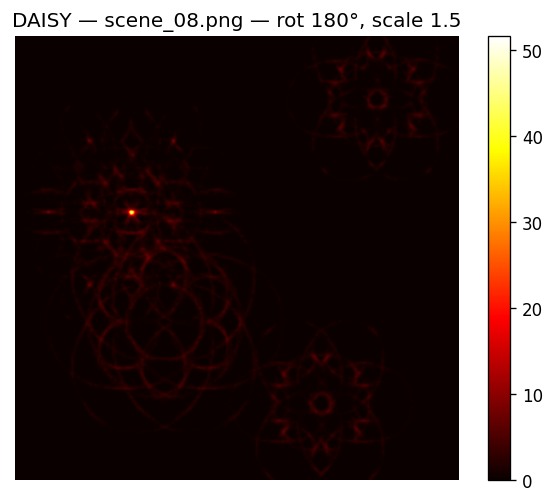

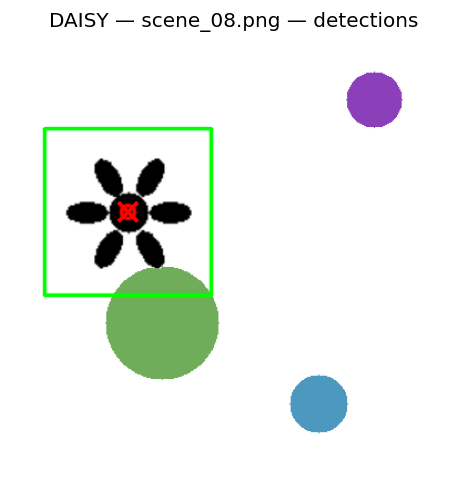

Saved: scene_08_acc_heatmap.png scene_08_detections.png
[DAISY] scene_09.png: 1 detections
  Detected center: (84, 170)  rot=75°  scale=1.0  votes=49


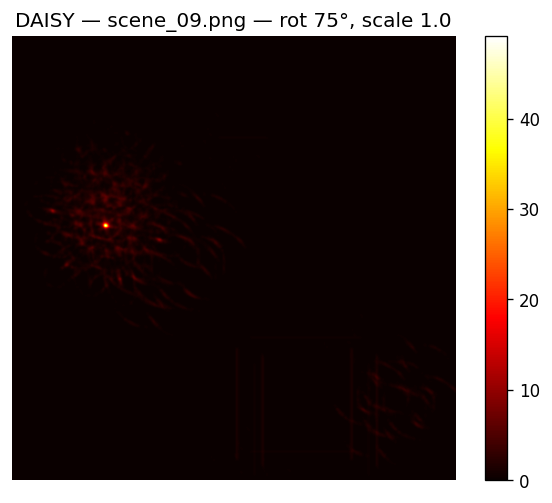

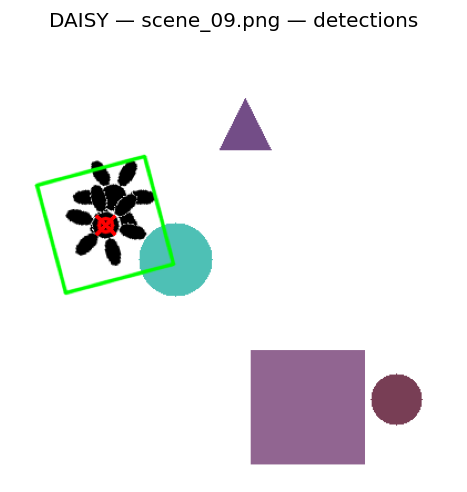

Saved: scene_09_acc_heatmap.png scene_09_detections.png
[DAISY] scene_10.png: 1 detections
  Detected center: (166, 252)  rot=180°  scale=2.0  votes=41


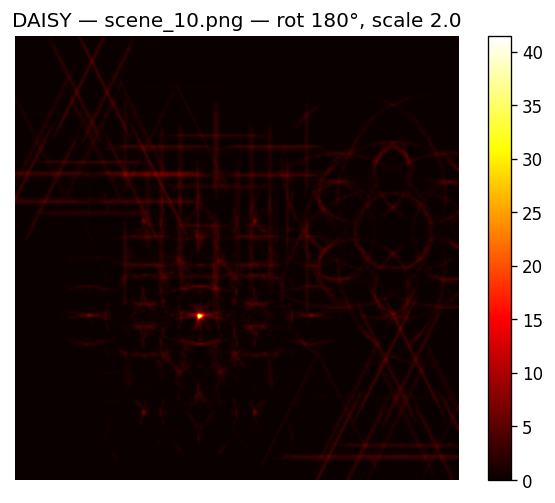

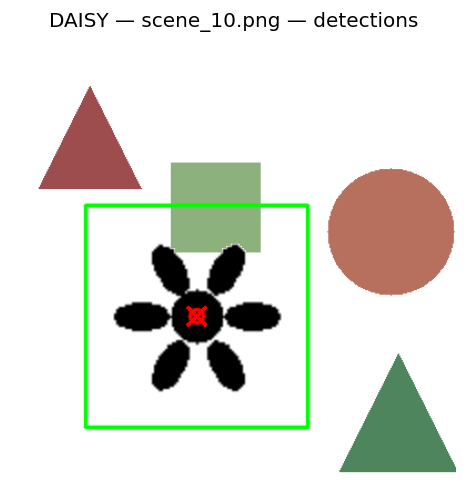

Saved: scene_10_acc_heatmap.png scene_10_detections.png
[DAISY] scene_11.png: 3 detections
  Detected center: (293, 87)  rot=255°  scale=1.0  votes=54
  Detected center: (221, 258)  rot=330°  scale=2.0  votes=43
  Detected center: (150, 86)  rot=270°  scale=1.5  votes=38


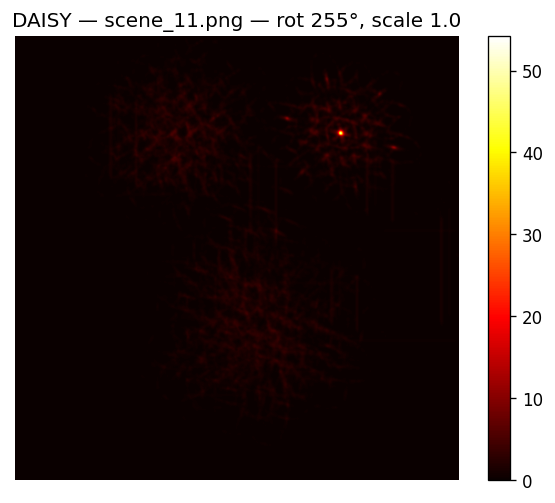

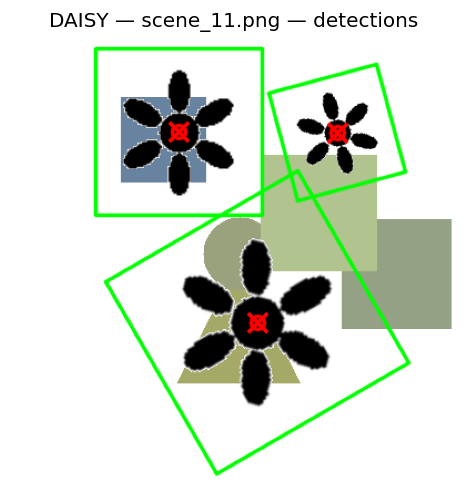

Saved: scene_11_acc_heatmap.png scene_11_detections.png
[DAISY] scene_12.png: 1 detections
  Detected center: (266, 191)  rot=60°  scale=1.0  votes=39


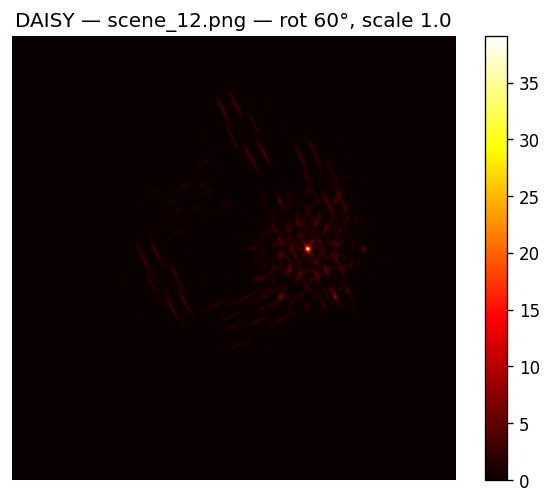

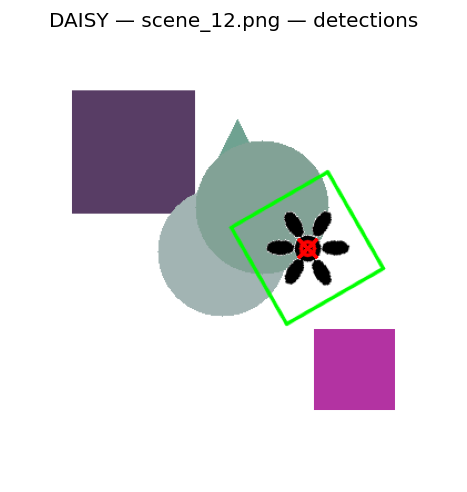

Saved: scene_12_acc_heatmap.png scene_12_detections.png
[DAISY] scene_13.png: 1 detections
  Detected center: (126, 329)  rot=30°  scale=1.0  votes=43


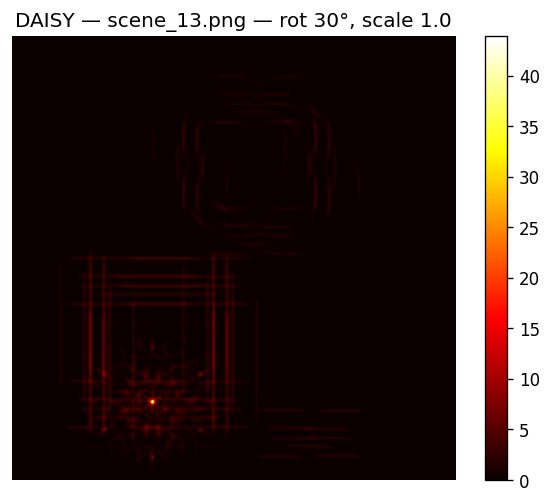

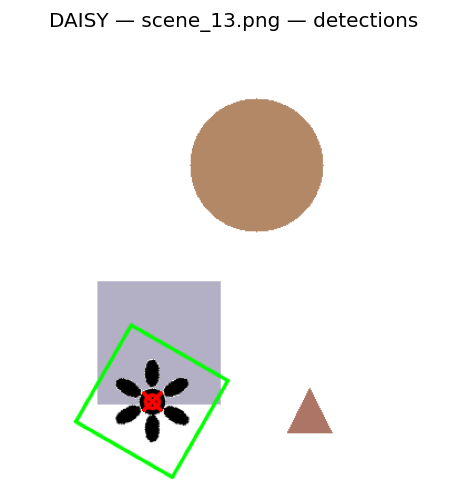

Saved: scene_13_acc_heatmap.png scene_13_detections.png
[DAISY] scene_14.png: 2 detections
  Detected center: (127, 257)  rot=45°  scale=1.5  votes=47
  Detected center: (286, 87)  rot=285°  scale=1.5  votes=37


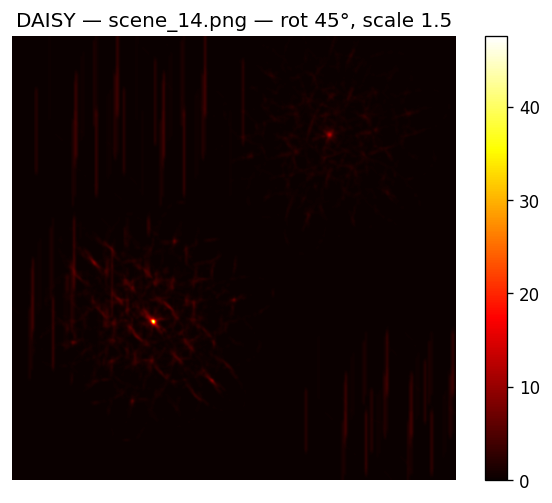

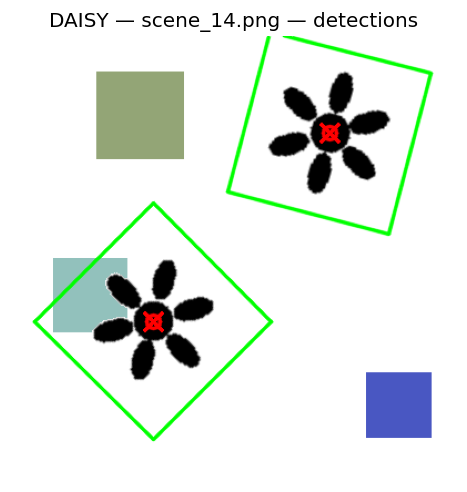

Saved: scene_14_acc_heatmap.png scene_14_detections.png
[DAISY] scene_15.png: 1 detections
  Detected center: (148, 254)  rot=45°  scale=1.0  votes=46


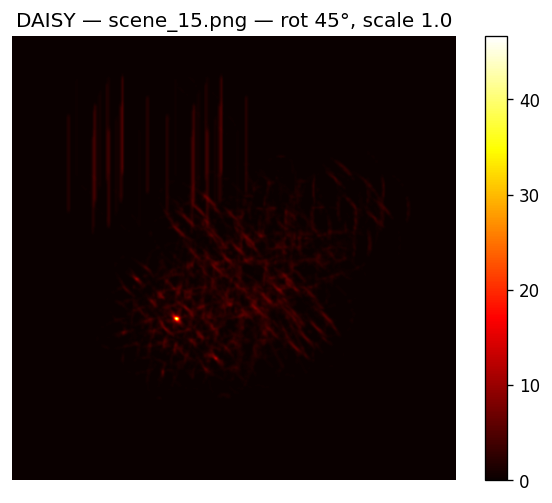

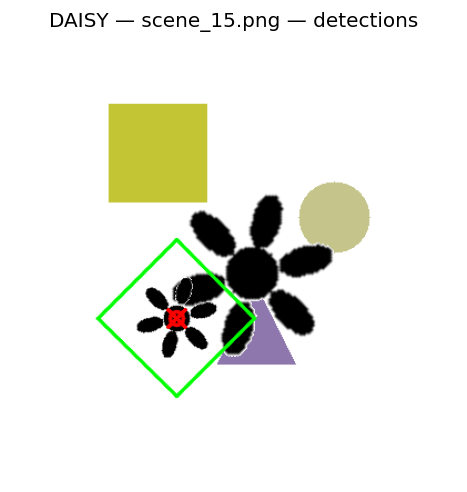

Saved: scene_15_acc_heatmap.png scene_15_detections.png
[DAISY] scene_17.png: 1 detections
  Detected center: (268, 164)  rot=165°  scale=1.5  votes=43


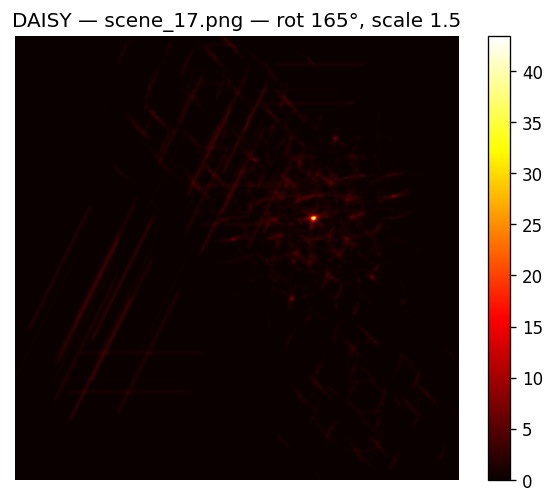

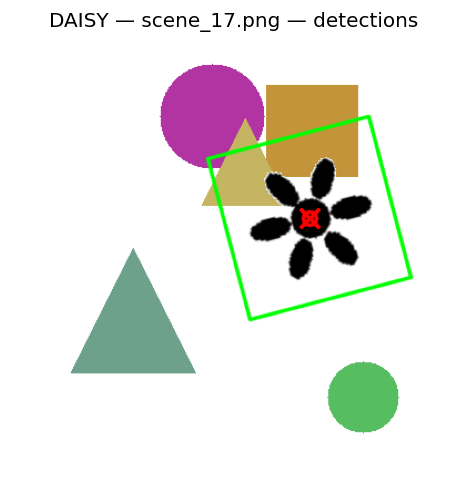

Saved: scene_17_acc_heatmap.png scene_17_detections.png


In [42]:
run_dataset(daisy_template_path, daisy_scene_paths[8:18], tag="DAISY")

[FISH] scene_00.png → Detected center: (266, 224) rot=285° scale=1.0


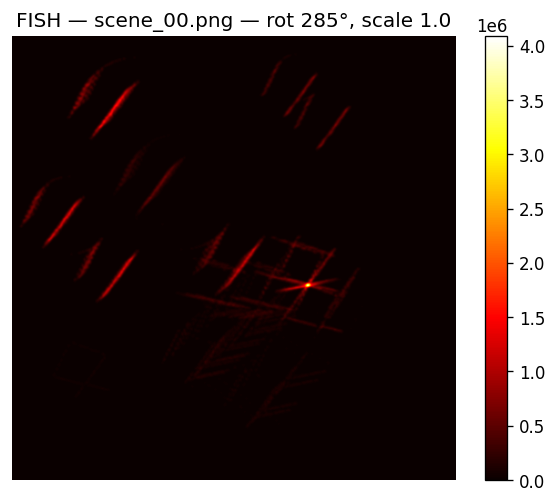

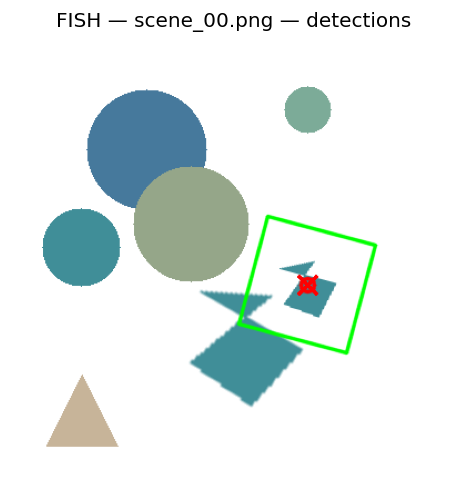

Saved: scene_00_acc_heatmap.png scene_00_detections.png
[FISH] scene_01.png → Detected center: (166, 198) rot=345° scale=1.0
[FISH] scene_01.png → Detected center: (284, 200) rot=60° scale=2.0
[FISH] scene_01.png → Detected center: (101, 244) rot=255° scale=1.0


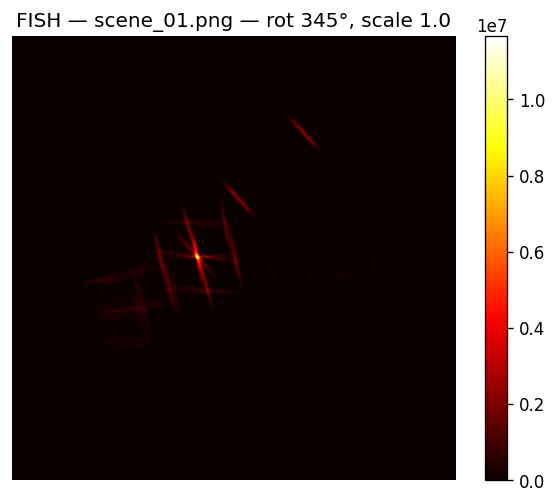

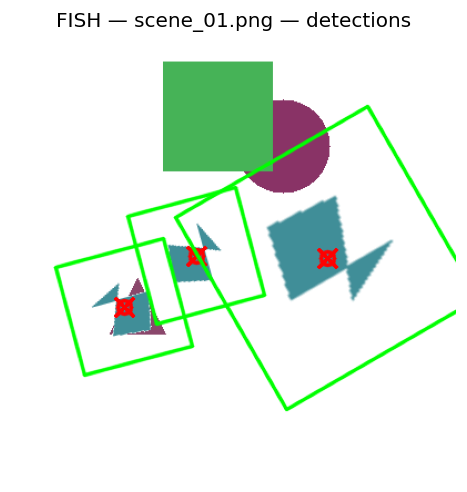

Saved: scene_01_acc_heatmap.png scene_01_detections.png
[FISH] scene_02.png → Detected center: (210, 262) rot=330° scale=2.0
[FISH] scene_02.png → Detected center: (241, 104) rot=45° scale=1.5


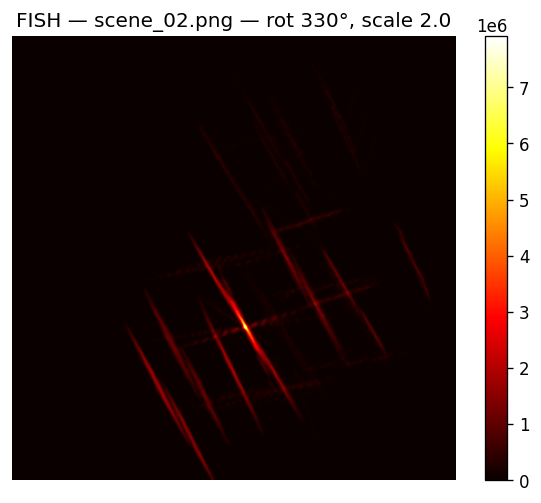

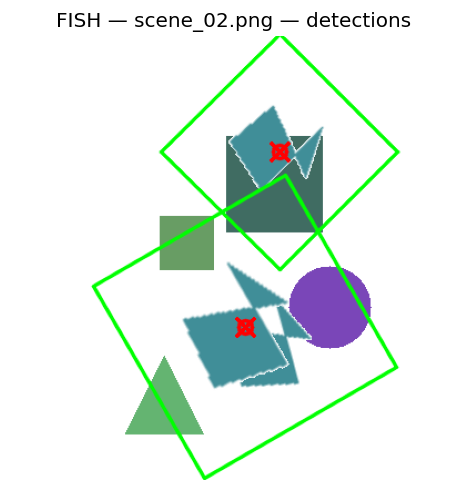

Saved: scene_02_acc_heatmap.png scene_02_detections.png
[FISH] scene_03.png → Detected center: (106, 128) rot=345° scale=1.0


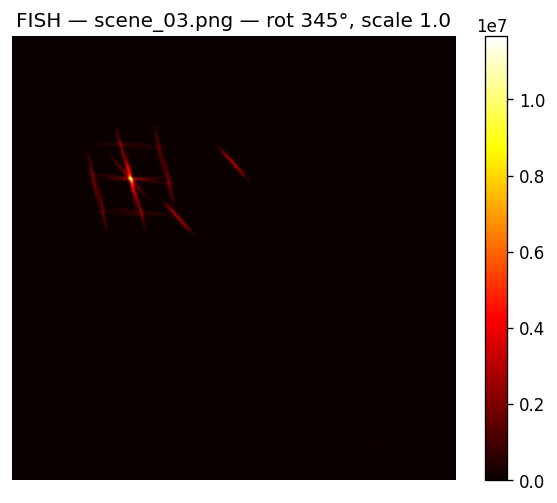

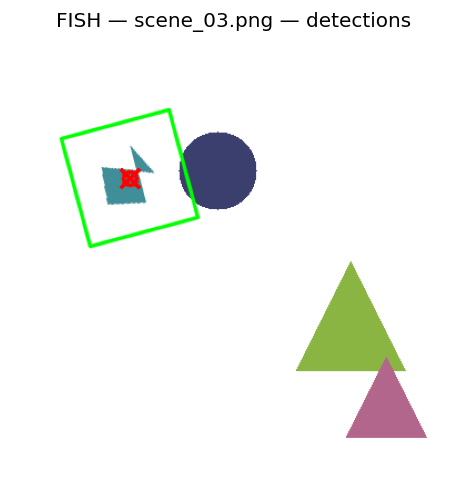

Saved: scene_03_acc_heatmap.png scene_03_detections.png
[FISH] scene_04.png → Detected center: (202, 309) rot=60° scale=1.0
[FISH] scene_04.png → Detected center: (267, 157) rot=300° scale=1.5


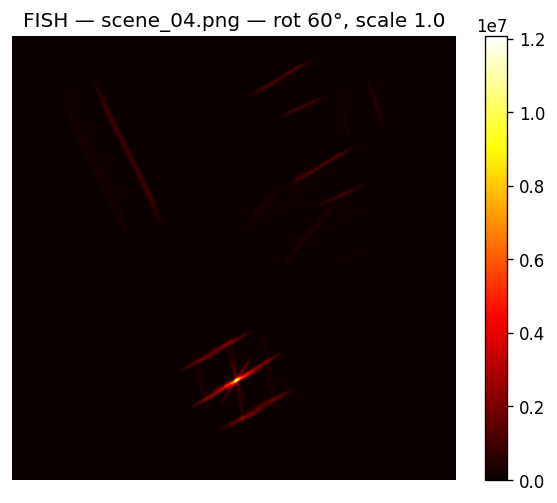

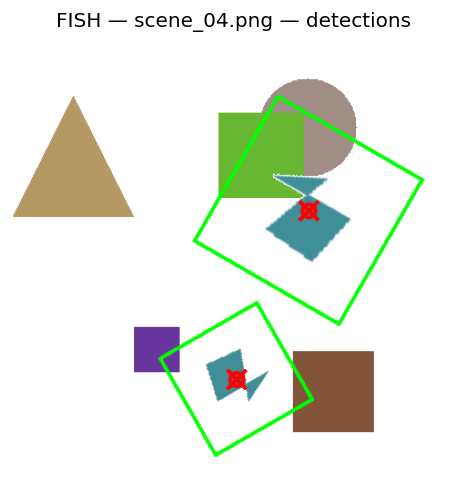

Saved: scene_04_acc_heatmap.png scene_04_detections.png
[FISH] scene_05.png → Detected center: (176, 234) rot=105° scale=1.5


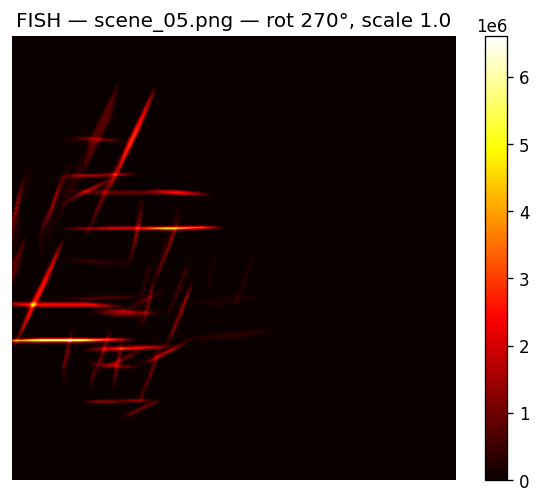

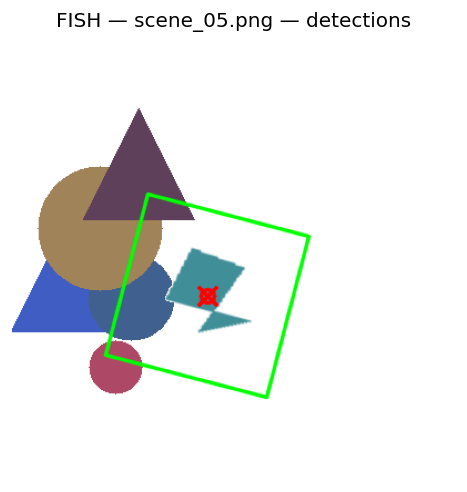

Saved: scene_05_acc_heatmap.png scene_05_detections.png
[FISH] scene_06.png → Detected center: (137, 187) rot=0° scale=1.0


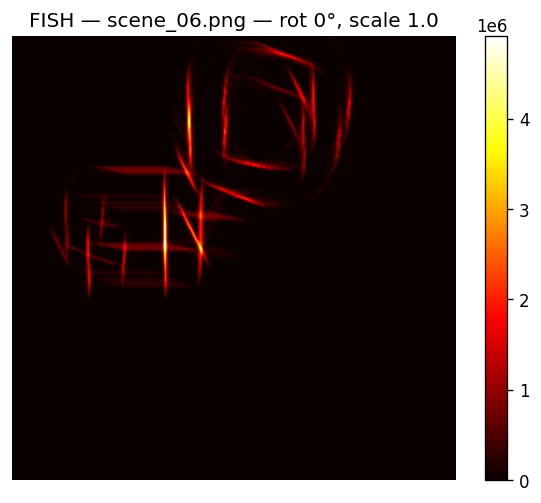

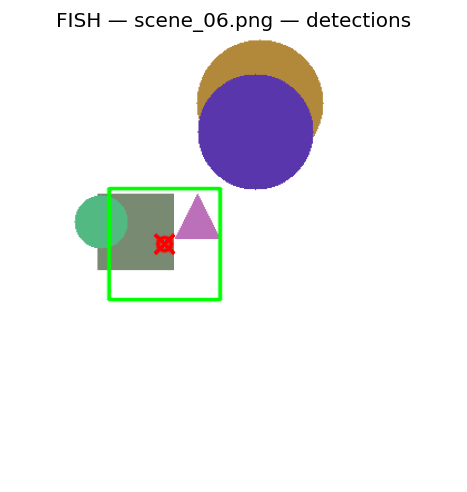

Saved: scene_06_acc_heatmap.png scene_06_detections.png
[FISH] scene_07.png → Detected center: (229, 198) rot=315° scale=2.0
[FISH] scene_07.png → Detected center: (303, 147) rot=105° scale=1.5


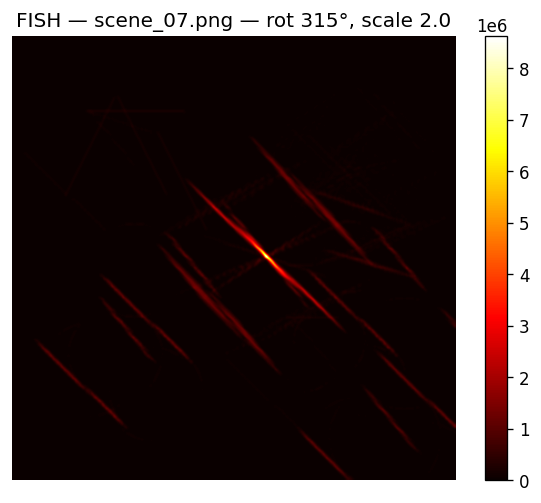

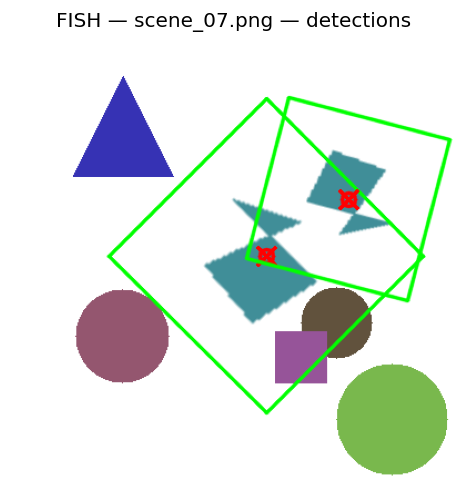

Saved: scene_07_acc_heatmap.png scene_07_detections.png
[FISH] scene_08.png → Detected center: (104, 158) rot=180° scale=1.5


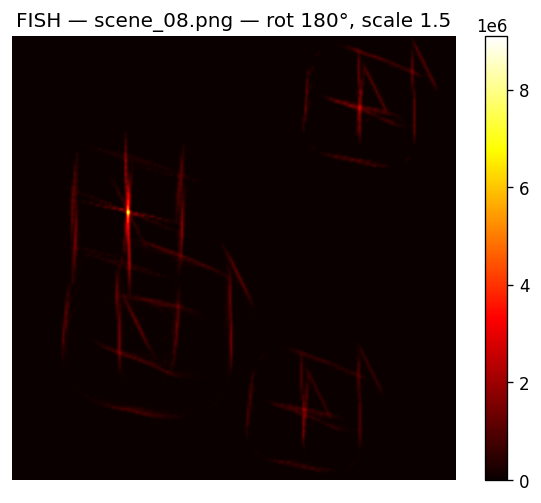

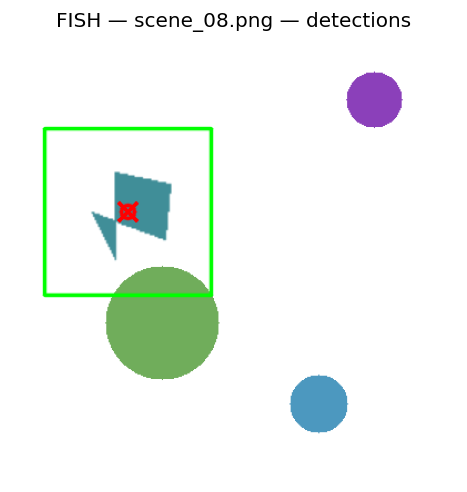

Saved: scene_08_acc_heatmap.png scene_08_detections.png
[FISH] scene_09.png → Detected center: (84, 170) rot=75° scale=1.0


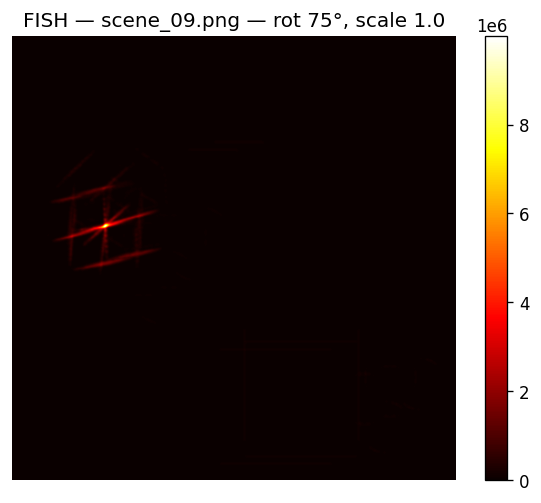

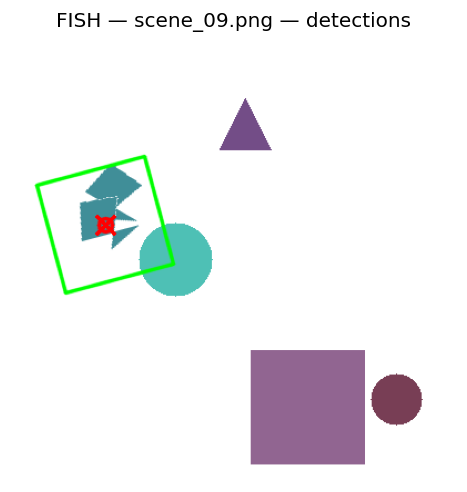

Saved: scene_09_acc_heatmap.png scene_09_detections.png


In [34]:
run_dataset_fish_robust(fish_template_path, fish_scene_paths[:10], tag="FISH")

## 9) Evaluation

- The daisy template was easier to implement and has clearer peaks. 

- The daisy template was easier to detect. I think the reason is it being more distinct from the other shapes and easier to distinguish. The fish template is generic and has sharp edges, resulting in more mistakes. Also, the daisy template has less rotational probabilities, because it is round its shape repeats periodically and therefore is easier to detect.


## 10) Failure cases
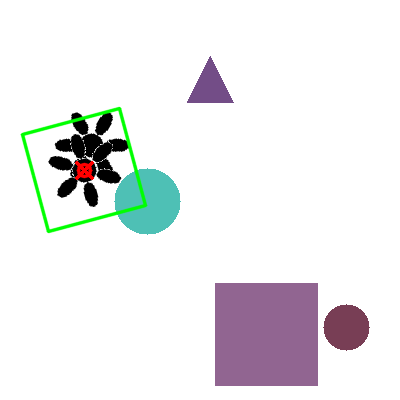 

**1) Daisy scene_09**


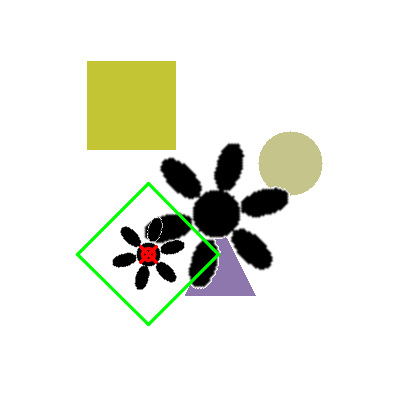

**2) Daisy scene_15**


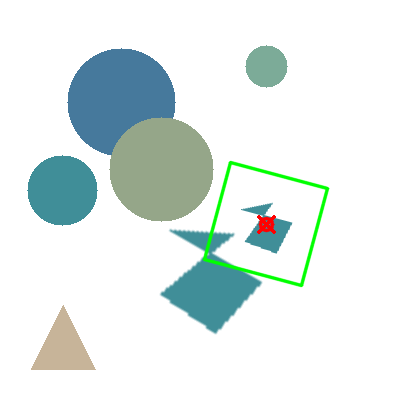

**3) Fish scene_00**


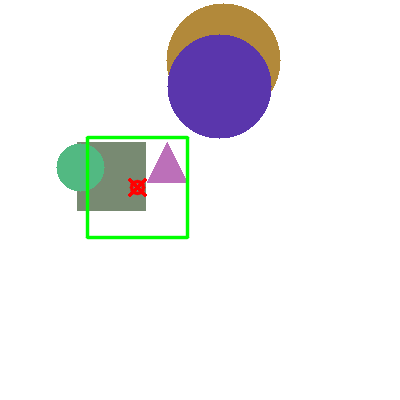

**4) Fish scene_06**



